### Juan Francisco Vazquez Rivera - 35077

# EDA y preprocesamiento - Clasificación del mantenimiento predictivo de máquinas
## Introduction

En este notebook, construyo unas canalizaciones de preprocesamiento para características numéricas y categóricas antes de obtener resultados de Análisis exploratorio de datos (EDA) con el dataset de clasificación del mantenimiento predictivo de máquinas.

El dataset sintético de 10,000 registros simula condiciones reales de la industria. Cada fila representa un punto de datos de una máquina. El objectivo es predecir el fracaso con la función de **_binary classification_**. 

Enlace de este dataset de Kaggle: https://www.kaggle.com/datasets/shivamb/machine-predictive-maintenance-classification

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer

Se carga el dataset con un Dataframe de pandas

In [2]:
data = pd.read_csv('../data/predictive_maintenance.csv')
data

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure
...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,No Failure
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,No Failure
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,No Failure
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,No Failure


## Información and estadísticas

El método de `.info()` muestra número de filas, lista de columnas, conteo de valores no nulos por columna, tipo de dato (dtype) de cada columna y uso aproximado de memoria.

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


El método de `.describe().T` calcula estadísticas como count, mean, std, etc. Luego, intercambia filas y columnas; las estadísticas quedan en columnas y cada fila corresponde a una columna original del DataFrame.

In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Target,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0


Por lo tanto, hay 10 columnas:
 - UDI: Identificador único para cada punto de datos, con un rango que va del 1 al 10,000
 - Product ID: Identificador del producto que consiste en una letra que indica la variante de calidad (L, M o H) seguida de un número de serie específico para esa variante.
 - Type: Categoría de calidad del producto.
    - L (Low): Calidad baja (representa el 50% de los productos).
    - M (Medium): Calidad media (representa el 30% de los productos).
    - H (High): Calidad alta (representa el 20% de los productos).
 - Air temperature [K]: Generada mediante un proceso de caminata aleatoria (random walk), normalizada posteriormente a una desviación estándar de 2 K alrededor de 300 K.
 - Process temperature [K]: Generada también mediante un proceso de caminata aleatoria normalizada a una desviación estándar de 1 K, sumada a la temperatura del aire más 10 K.
 - Rotational speed [rpm]: Velocidad de rotación calculada a partir de una potencia de 2860 W, a la cual se le superpuso un ruido con distribución normal.
 - Torque [Nm]: Valores de torque distribuidos normalmente alrededor de 40 Nm con una desviación estándar ($\sigma$) de 10 Nm; no contiene valores negativos.
 - Tool wear [min]: La variante de calidad afecta este desgaste (H/M/L añaden 5/3/2 minutos respectivamente).
 - Target: Indica si la máquina ha fallado o no en binario (0: No Falla, 1: Falla)
 - Failure Type: Una descripción categórica de la causa raíz del fallo (por ejemplo: fallo de potencia, desgaste de herramienta, disipación de calor, etc.).

Para analizar, no debe incluirse 'UDI', 'Product ID', ni 'Failure Type' porque no son datos útiles para preprocesamiento.

## Visualización de Columnas Numéricas

Para visualizar las distribuciones de cada columna numérica, se utiliza la liberia de `seaborn` para crear un histplot con kernel density estimates (KDE).

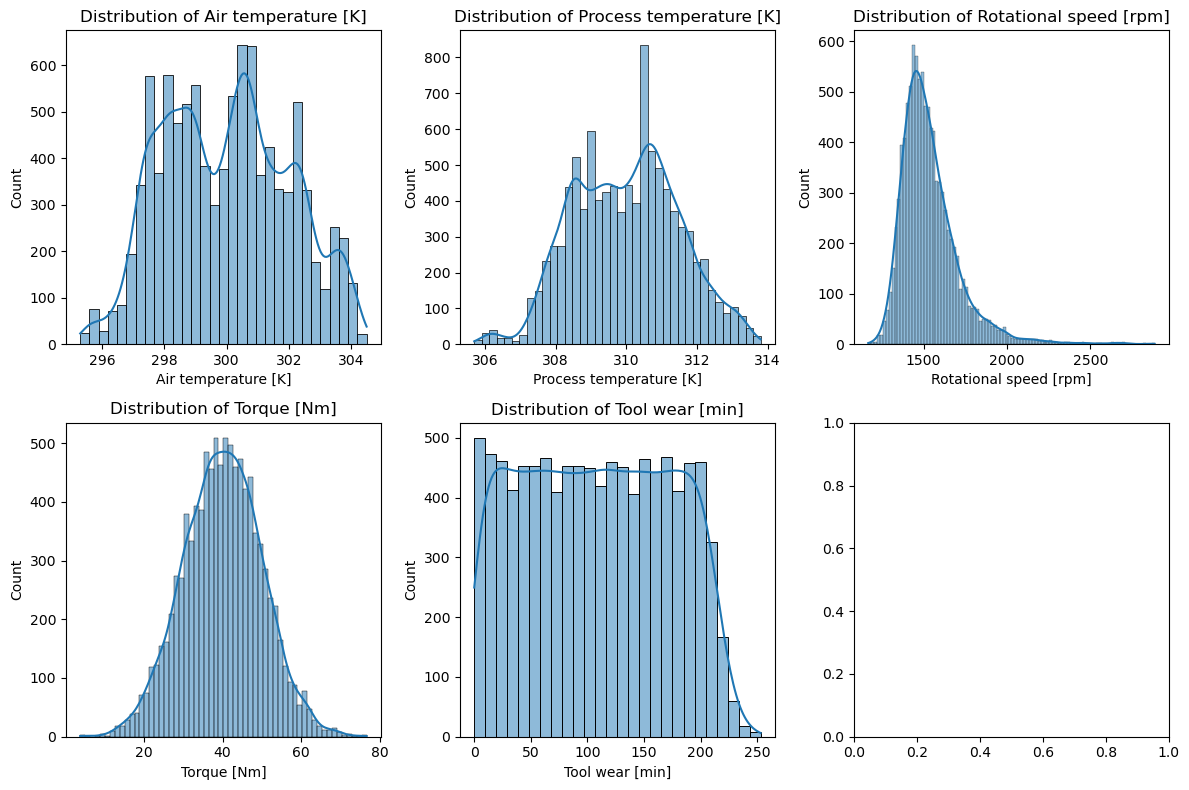

In [5]:
numerical_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axs = plt.subplots(2, 3, figsize=(12, 8))

# axs.ravel() aplasta el arreglo en 2D de axes al arreglo en 1D para iteración facil
# la funcción de zip empareja cada "cajita" de dibujo con el nombre de una columna
for ax, col in zip(axs.ravel(), numerical_cols):
    sns.histplot(data[col], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')

fig.tight_layout()

Por lo tanto, 
- `Air temperature`, `Process temperature`, y `Torque`: Indica que la mayoría de los datos están cerca del promedio (300 K para el aire, 40 Nm para el torque). Los valores muy altos o muy bajos son raros.
- `Rotational speed [rpm]`: Habrá que la "cola" del gráfico se extiende hacia un lado. Esto pasa porque la velocidad de rotación está calculada a partir de la potencia, y suele tener un límite físico o ruido específico.
- `Tool wear [min]`: A diferencia de las temperaturas, el desgaste de la herramienta suele ser constante. Habrá una distribución más plana o con barras repartidas.

## Visualización de Columna Categórica

Para visualizar las distribuciones de una columna categórica "Type", se utiliza la liberia de `seaborn` para crear un countplot, usanda barra para contar cada tipo.

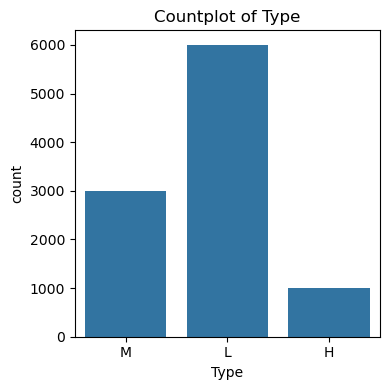

In [6]:
categorical_cols = ['Type']

fig, ax = plt.subplots(figsize=(4, 4))

sns.countplot(data=data, x=categorical_cols[0], ax=ax)
ax.set_title(f'Countplot of {categorical_cols[0]}')

plt.tight_layout()

Significa que un modelo de Machine Learning va a estar "entrenado" principalmente con máquinas de tipo L. Si las máquinas tipo H fallan de manera diferente, el modelo tendrá menos ejemplos para aprender sobre ellas.

El gráfico confirma que se cumplen las proporciones teóricas (50/30/20). Si vieras algo distinto, sabrías que hubo un error al cargar los datos.

El uso de One-Hot Encoding será una estrategia para 3 categorías claras, manteniendo el modelo simple y eficiente.

## Distribución de etiquetas de destino

Con una liberia de `seaborn`, `sns.countplot` cuenta cuantas maquinas fallan y cuántas no.

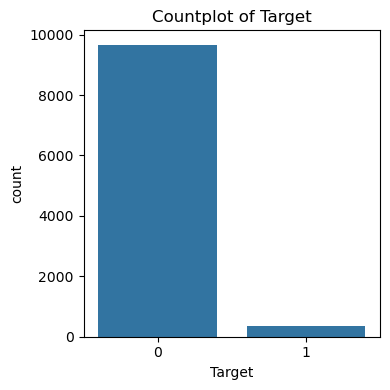

In [7]:
fig = plt.figure(figsize=(4, 4))
sns.countplot(data=data, x='Target')
plt.title('Countplot of Target')
plt.tight_layout()

En mantenimiento predictivo, lo normal es que este gráfico sea muy desigual. Verás una barra gigante en el `0` y una muy pequeña en el `1`.

Luego, los `sns.boxplots` comparan la distribución de cada sensor (temperatura, torque, etc.) cuando la máquina está bien vs. cuando falla.

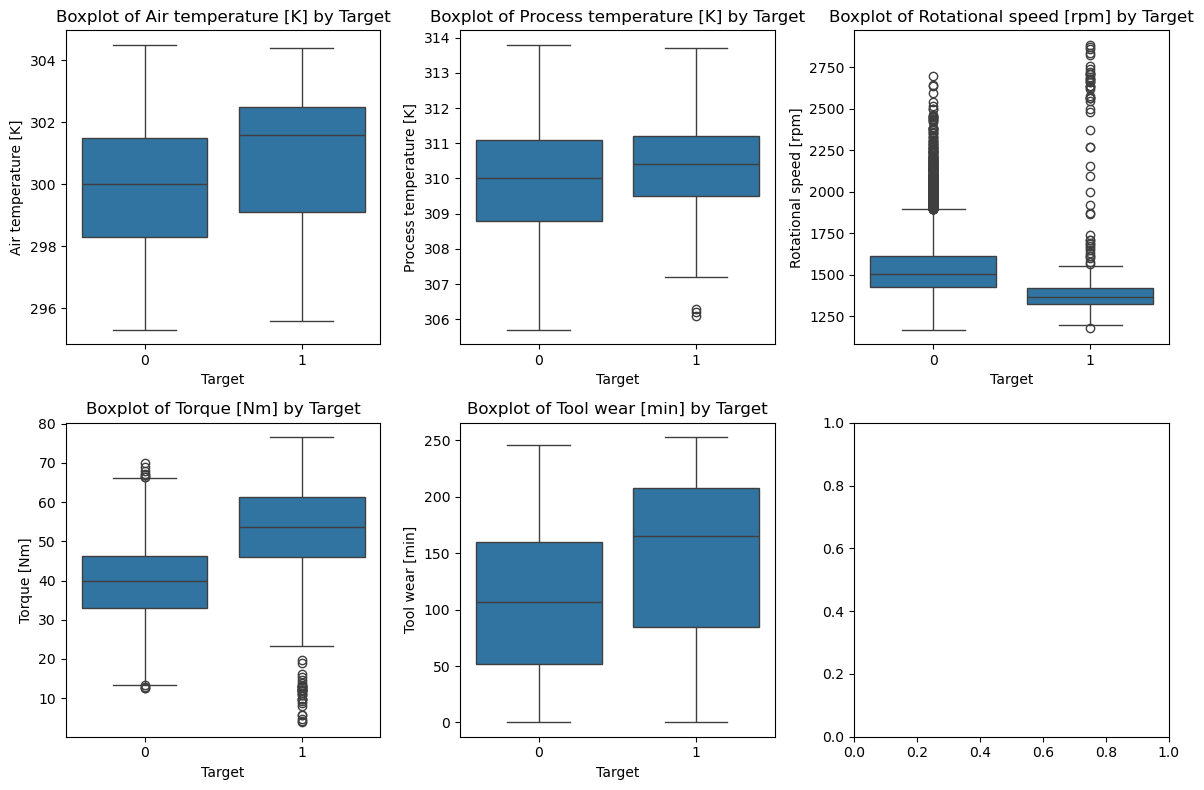

In [8]:
fig, axs = plt.subplots(2, 3, figsize=(12, 8))

for ax, col in zip(axs.ravel(), numerical_cols):
    sns.boxplot(data=data, x='Target', y=col, ax=ax)
    ax.set_title(f'Boxplot of {col} by Target')

fig.tight_layout()

Si las "cajitas" están a la misma altura, ese sensor no sirve mucho para predecir fallos.

Si la cajita del Target 1 está mucho más arriba (por ejemplo, en Torque o Tool wear), significa que valores altos en esos sensores son síntomas claros de una falla inminente.

Otra función de `sns.countplot` divide las máquinas por su tipo (L, M, H) y luego les pone color según si fallaron o no.

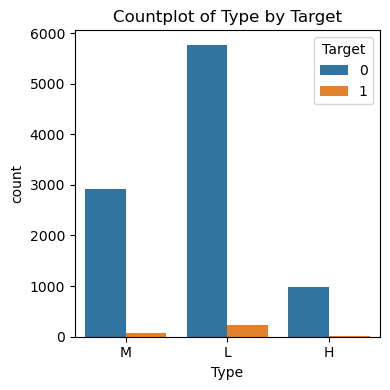

In [9]:
fig, xs = plt.subplots(figsize=(4, 4))

sns.countplot(data=data, x="Type", hue='Target', ax=xs)
xs.set_title(f'Countplot of Type by Target')

fig.tight_layout()

Aquí verás si las máquinas de tipo L (Low quality) fallan proporcionalmente más que las de tipo H (High quality).

La funcion de `sns.heatmap` calcula un número entre -1 y 1 para cada par de variables.
- 1.00: Relación perfecta.
- Entre 0.00 y -1.00: No tienen nada que ver.

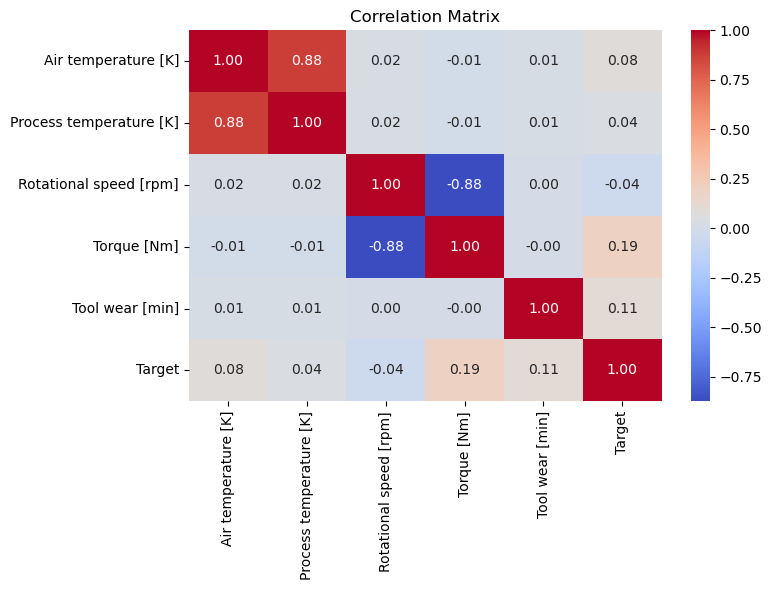

In [10]:
corr_matrix = data[['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target']].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()

Busca la fila/columna de Target. Los números más altos (cercanos a 1 o -1) son tus mejores amigos; indican qué sensores están más conectados con las fallas.

Verás una correlación muy alta entre Air temperature y Process temperature por 0.88, lo que significa que si el aire está caliente, el proceso también. Sin embargo, en modelos avanzados esto se llama multicolinealidad.

## Manejo de valores faltantes

La funcion de `.isnull()` marca cada celda como True (si falta el dato) o False (si el dato está presente). 

`sum()` suma esos valores (donde True vale 1). El resultado es el número total de celdas vacías por cada columna.

<Axes: >

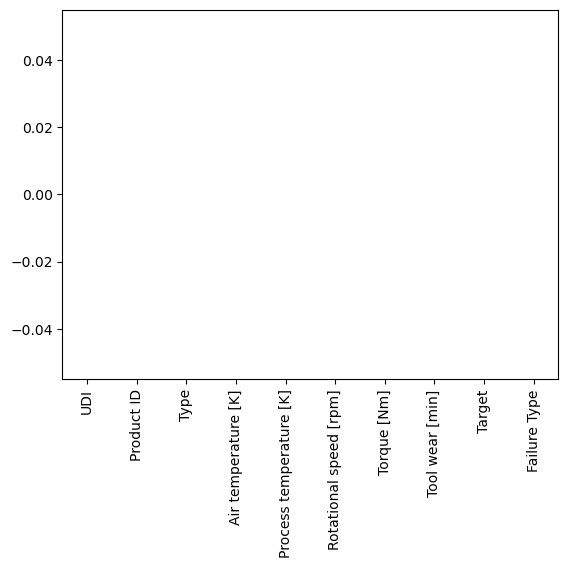

In [11]:
missing_counts = data.isnull().sum()
missing_counts.plot(kind='bar')

`mean()` calcula la proporción (ej. 0.05). Al multiplicar por 100, obtienes el porcentaje (%) de datos faltantes.

In [12]:
missing_percent = data.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

UDI                        0.0
Product ID                 0.0
Type                       0.0
Air temperature [K]        0.0
Process temperature [K]    0.0
Rotational speed [rpm]     0.0
Torque [Nm]                0.0
Tool wear [min]            0.0
Target                     0.0
Failure Type               0.0
dtype: float64

Por lo tanto, este dataset sintético no tiene valores nulos, pero este es una buena práctica profesional por dos razones:
 1. Validación de Carga: el archivo `predictive_maintenance.csv` se leyó correctamente y no hubo errores de formato que "borraran" datos
 2. Preparación para el Pipeline: 0% de nulos garantiza que si mañana conectas el modelo a una máquina real que falla y deja de enviar la temperatura, este modelo no se romperá y podrá seguir prediciendo.

## Preprocessing pipelines

Preprocessing pipeline es una fabrica de modelo de Machine Learning que limpia los datos, y luego que los organiza de forma que el modelo pueda entenderlos matemáticamente sin errores de sesgo.

`ColumnTransformer` es un 'cerebro' que decide qué transformación le toca a cada columna.
 1. Ruta Categórica ('Tipo')
    - `SimpleImputer(strategy='most_frequent')`: Si una máquina no tiene registrado su "Type", le asigna el tipo más común (probablemente 'L').
    - `OneHotEncoder`: Las letras 'L', 'M' y 'H' no se pueden sumar ni multiplicar. Esta herramienta las convierte en columnas binarias (ej. Type_L = 1 o 0)
 2. Ruta Numérica ('Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', y 'Tool wear [min]')
    - `SimpleImputer(strategy='median')`: Rellena huecos con el valor central, lo cual es más seguro que el promedio si hay datos muy locos (outliers).
    - `StandardScaler`: Es vital. Convierte valores como "2860 rpm" y "300 K" a una escala común (usualmente entre -3 y 3). Sin esto, el modelo pensaría que las RPM son "más importantes" solo porque el número es más grande.

In [13]:
preprocessing_pipeline = make_pipeline(
    ColumnTransformer(
        transformers=[
            ('cat', make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore')), categorical_cols),
            ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), numerical_cols),
        ],
        remainder='passthrough',
    )
)


In [14]:
x = data[numerical_cols + categorical_cols] # Columnas relevantes para predecir
y = data['Target']

# Separar el dataset entre los conjuntos de training y testing
# stratify=y garantiza que la distribución de clases se conserve en ambos conjuntos
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

Con `stratify=y`, train_test_split mantienen la misma proporción de fallas en ambos grupos (80/20). Si hay un 4% de fallas en el total, habrá un 4% en entrenamiento y un 4% en prueba.

Segun el resultado de countplot, el gráfico de **Training** Set llegará hasta los 8,000 registros y el de **Testing** hasta los 2,000. Lo importante aquí es que la "barrita" pequeña del **Target 1** sea proporcionalmente igual en ambos. Esto confirma que un modelo será evaluado en condiciones justas.

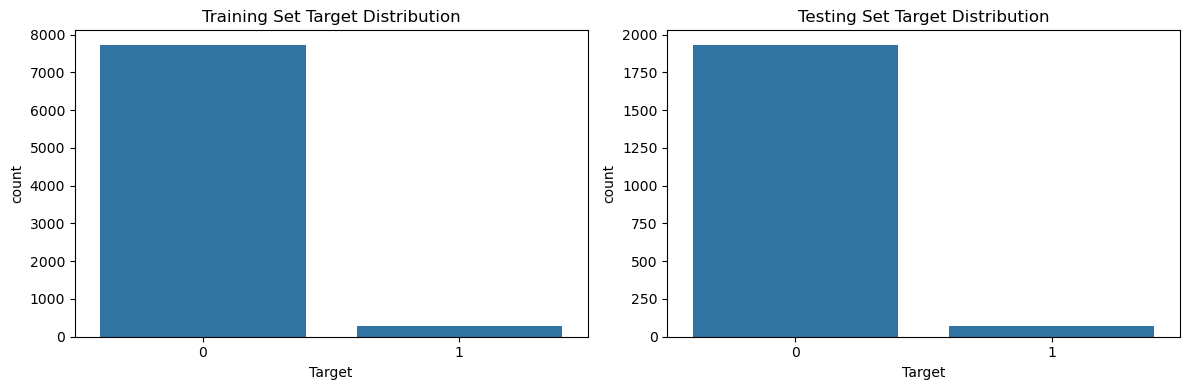

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=y_train, ax=axs[0])
axs[0].set_title('Training Set Target Distribution')
sns.countplot(x=y_test, ax=axs[1])
axs[1].set_title('Testing Set Target Distribution')
fig.tight_layout()

`fit_transform(x_train, y_train)`: El pipeline aprende (fit) cuál es la mediana y la desviación estándar de tus datos de entrenamiento y luego las aplica (transform).

In [16]:
x_train_processed = preprocessing_pipeline.fit_transform(x_train, y_train)
x_train_processed

array([[ 0.        ,  0.        ,  1.        , ..., -0.46060741,
         0.71830476, -0.84399726],
       [ 0.        ,  0.        ,  1.        , ..., -0.77557391,
         0.63845583,  0.38226308],
       [ 0.        ,  0.        ,  1.        , ..., -1.00765448,
         0.5586069 ,  0.46086951],
       ...,
       [ 1.        ,  0.        ,  0.        , ..., -0.41640159,
         0.09947555, -1.23702942],
       [ 0.        ,  1.        ,  0.        , ..., -0.12353801,
         0.23921118,  0.08355864],
       [ 0.        ,  1.        ,  0.        , ..., -0.42745305,
         0.6783803 , -1.63006158]], shape=(8000, 8))

`transform(x_test)`: El pipeline NO aprende nada nuevo. Aplica las mismas reglas (la misma mediana y escala) que aprendió del grupo de entrenamiento.

In [17]:
x_test_processed = preprocessing_pipeline.transform(x_test)
x_test_processed

array([[ 0.        ,  1.        ,  0.        , ..., -1.07396322,
         2.2653778 ,  0.71241009],
       [ 0.        ,  1.        ,  0.        , ..., -0.14564092,
         0.0096455 ,  0.42942694],
       [ 0.        ,  1.        ,  0.        , ...,  0.10854256,
        -0.23988241,  1.59280213],
       ...,
       [ 0.        ,  0.        ,  1.        , ..., -0.51586469,
         0.27913564,  0.20932893],
       [ 0.        ,  0.        ,  1.        , ..., -0.64848216,
         0.63845583,  1.35698283],
       [ 0.        ,  0.        ,  1.        , ...,  2.37961675,
        -1.83686103, -1.11125913]], shape=(2000, 8))

Si el pipeline aprendiera del set de prueba, estarías haciendo "trampa" (Data Leakage). Por ejemplo, si un estudiante viera las respuestas del examen final mientras está estudiando.

## Construir un modelo de clasificación

Imagina que el preprocessing_pipeline es la cocina donde se preparan los ingredientes y la LogisticRegression() es el chef. Al unirlos en un solo classification_model, crea una línea de producción completa.

Cada vez que le pidas al modelo una predicción, él mismo se encargará de escalar los números y convertir las categorías del nuevo dato antes de analizarlo. Esto evita errores manuales.

In [18]:
classification_model = make_pipeline(
    preprocessing_pipeline,
    LogisticRegression()
)

classification_model

,steps,"[('pipeline', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('columntransformer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3


el modelo de Regresión Logística analiza las 8,000 filas de entrenamiento. Busca patrones: por ejemplo, observa que cuando el Torque sube y las RPM bajan drásticamente, el Target suele ser 1 (falla).

In [19]:
classification_model.fit(x_train, y_train)

,steps,"[('pipeline', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('columntransformer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3


Le entregas al modelo las 2,000 máquinas de prueba (sin las respuestas). El modelo aplica lo que aprendió y genera su "opinión" (`y_test_pred`). Por lo tanto, el modelo se enfrenta a datos de ceros y unos que nunca vio durante el entrenamiento.

In [20]:
y_test_pred = classification_model.predict(x_test)
y_test_pred

array([1, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [21]:
y_test.values

array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

Hay los valores de **"Target Predicted"** y **"Target Actual"** que son iguales (ambos 0 o ambos 1). Sin embargo, tambien hay los unos que son diferentes:
- Falsos Positivos: Cuando el modelo predice 1, pero la máquina estaba bien (0), en la industria, esto significa gastar dinero en mantenimiento innecesario.
- Falsos Negativos: Cuando el modelo predice 0, pero la máquina falló (1), este es el error más peligroso, ya que la máquina se rompe sin aviso.

la mayoría de los registros en un dataset de mantenimiento serán 0 (No Failure). Por eso, no te dejes engañar si el modelo parece muy bueno; lo que realmente importa es cuántos de los 1 reales logró detectar.

In [22]:
x_test['Target Predicted'] = y_test_pred
x_test['Target Actual'] = y_test.values
x_test

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type,Target Predicted,Target Actual
2997,300.5,309.8,1345,62.7,153,L,1,0
4871,303.7,312.4,1513,40.1,135,L,0,0
3858,302.5,311.4,1559,37.6,209,L,0,0
951,295.6,306.3,1509,35.8,60,H,0,0
6463,300.5,310.0,1358,60.4,102,H,0,0
...,...,...,...,...,...,...,...,...
1686,297.9,307.3,1663,28.7,7,H,0,0
6952,300.8,311.3,1498,40.2,73,L,0,0
9954,298.1,307.9,1446,42.8,121,M,0,0
5728,302.4,311.9,1422,46.4,194,M,0,0


Resumen del flujo
1. Ensamblas: Unir limpieza y algoritmo.
2. Entrenas: El algoritmo aprende patrones de falla.
3. Predices: El modelo apuesta sobre datos nuevos.
4. Comparas: Verificar qué tan cerca estuvo la apuesta de la realidad.